<a href="https://colab.research.google.com/github/PallavKhanal/MachineLearningProjects/blob/main/Ames_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Liner Regression**


Imagine you're trying to guess how much a house costs. You notice that bigger houses cost more money. If you drew that on paper — dots for each house, left-right = size, up-down = price — you'd see the dots go from bottom-left to top-right.
Linear regression is just drawing the best straight line through those dots.
That line lets you say: "If a house is THIS big, it probably costs THAT much."
That's it. That's linear regression.

📐 The Line Itself
A straight line has a simple equation you probably remember from school:
y = mx + b
In ML language, we write it as:
ŷ = β₀ + β₁x

ŷ (y-hat) = your prediction
β₀ = the intercept — where the line crosses the y-axis (the "base" value when x = 0)
β₁ = the slope — how much y goes up when x goes up by 1
x = your input feature (e.g. house size)

With multiple features (size, bedrooms, age of house...), it extends naturally:
ŷ = β₀ + β₁x₁ + β₂x₂ + β₃x₃ + ...
You're still drawing a "line" — just in higher-dimensional space. The math is identical.

🎯 How Do We Find the Best Line? — Minimizing MSE
Any line you draw will be wrong for most points. The question is: which line is the least wrong?
We measure wrongness using Mean Squared Error (MSE):
MSE = (1/n) Σ (yᵢ - ŷᵢ)²
In plain English:

For each data point, find the gap between the real value and your prediction
Square that gap (so negatives don't cancel positives, and big errors are punished more)
Average all the squared gaps

Your goal: find β values that make this number as small as possible.
Why squared and not absolute value? Squaring makes the math smooth and differentiable everywhere, which makes optimization much easier. It also punishes big outlier errors more severely, which is sometimes desirable (and sometimes not).

🔬 Deep Math: The OLS Closed-Form Solution
This is the elegant part. In matrix form, your data looks like:

X = matrix of all your input features, shape (n × p). We add a column of 1s for the intercept.
y = vector of true outputs, shape (n × 1)
β = vector of coefficients we're solving for, shape (p × 1)

The model says: Xβ ≈ y
MSE in matrix form is:
L(β) = (1/n) ||y - Xβ||²
     = (1/n) (y - Xβ)ᵀ(y - Xβ)
To minimize, take the derivative with respect to β and set it to zero:
∂L/∂β = -2Xᵀ(y - Xβ) = 0
Expand:
Xᵀy - XᵀXβ = 0
XᵀXβ = Xᵀy
Solve for β (assuming XᵀX is invertible):
β = (XᵀX)⁻¹Xᵀy
This is the Normal Equation — the exact, closed-form answer. No iteration needed.
Why not always use this?
Inverting a matrix is O(p³) — if you have 10,000 features, computing (XᵀX)⁻¹ becomes brutally slow. That's when gradient descent wins.

⛰️ Gradient Descent Derivation
Instead of solving analytically, gradient descent says: start somewhere, then keep walking downhill on the loss surface.
We already found the gradient:
∂MSE/∂β = -(2/n) Xᵀ(y - Xβ)
The update rule at each step is:
β ← β - α · ∂MSE/∂β
β ← β + (2α/n) Xᵀ(y - Xβ)
Where α (alpha) is the learning rate — how big a step you take each time.

Too large → you overshoot and diverge
Too small → you get there eventually, but very slowly
Just right → smooth convergence

You repeat this until the β values stop changing meaningfully. That's it. Gradient descent for linear regression is just repeatedly applying that one formula.

📏 Feature Scaling
Here's a problem. Say you're predicting house price using:

Square footage: ranges from 500 to 5,000
Number of bathrooms: ranges from 1 to 5

The gradient for square footage will be massive compared to bathrooms — not because it matters more, but just because the numbers are bigger. This makes gradient descent zigzag wildly and converge slowly.
Solution: scale your features so they're on the same playing field.
Standardization (Z-score): subtract mean, divide by std. Result: mean = 0, std = 1
x_scaled = (x - μ) / σ
Min-Max Normalization: squish everything into [0, 1]
x_scaled = (x - x_min) / (x_max - x_min)
Standardization is almost always preferred for linear models because it handles outliers better and the resulting coefficients are directly comparable — a larger β truly means a more important feature.

🚨 Handling Outliers
Linear regression is sensitive to outliers because squaring errors makes extreme values dominate the loss.
One house listed at $50M in a dataset of $200k houses? The model will bend the line toward that single point to reduce its massive squared error.
Your options:

Remove them if they're data errors or genuinely irrelevant
Cap them (winsorization) — clip values beyond the 1st/99th percentile
Log-transform the target — log(price) compresses extreme values dramatically and is very common in housing datasets
Use a robust loss like Huber loss instead of MSE — it's quadratic for small errors but linear for large ones, reducing outlier influence


🏋️ Regularization — Punishing Complexity
Here's the core problem regularization solves.
Imagine you have 100 features but only 80 data points. The model can find β values that perfectly fit every training point — but those coefficients will be enormous and wildly overfitted. It memorized noise.
Regularization adds a penalty term to the loss function for large coefficients:
Regularized Loss = MSE + λ · (penalty on β)
λ (lambda) controls how hard you penalize. Higher λ = simpler model. Lower λ = closer to plain OLS.

Ridge Regression (L2)
Loss = MSE + λ Σ βⱼ²
Penalty = sum of squared coefficients.

Shrinks all coefficients toward zero, but never exactly to zero
Works great when many features all contribute a little
Keeps all features in the model
Has a closed-form solution: β = (XᵀX + λI)⁻¹Xᵀy — the λI term also fixes the invertibility problem when XᵀX is singular


Lasso Regression (L1)
Loss = MSE + λ Σ |βⱼ|
Penalty = sum of absolute values of coefficients.

Actually drives some coefficients to exactly zero
This is automatic feature selection — Lasso decides which features don't matter
Works great when you suspect only a few features are truly important (sparse solution)
No closed-form solution — requires iterative methods (coordinate descent)

Why does L1 produce zeros but L2 doesn't?
Geometrically: the L2 penalty region is a smooth sphere. The L1 penalty region is a diamond with corners. The loss function almost always intersects the diamond at a corner, where one or more coordinates are exactly zero. The sphere has no corners, so it almost never lands exactly at zero on any axis.

ElasticNet
Loss = MSE + λ₁ Σ |βⱼ| + λ₂ Σ βⱼ²
A combination of L1 and L2. You get:

Feature selection from the L1 part
Stability from the L2 part (Lasso can behave erratically when features are correlated — ElasticNet fixes this)

Use ElasticNet when you have many features, some correlated, and you want sparse solutions but more stability than pure Lasso.

In [ ]:
#imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')


In [ ]:
#loading the data

# We're using the Ames Housing dataset — it's a classic ML dataset
# with 1,460 houses sold in Ames, Iowa between 2006 and 2010.
# Each row is one house. Each column is one property of that house.
#
# fetch_openml gives us the features (X) and target (y) separately.
# We immediately combine them into one DataFrame called `df` because
# it's easier to do cleaning and feature engineering when everything
# is in one place.

ames = fetch_openml(name="house_prices", as_frame=True)
# `as_frame=True` means: give me pandas DataFrames, not numpy arrays.
# Without this, we'd get raw numpy which is harder to work with here.

df = ames.data.copy()
# .copy() is important — without it, `df` is just a reference to the
# original data. Any changes we make would modify the original too.
# .copy() gives us our own independent copy to work with safely.

df['SalePrice'] = ames.target
# The target (what we want to predict) comes back separately from
# fetch_openml. We stick it back into the DataFrame so we can
# do EDA (Exploratory Data Analysis) on it alongside the features.

df['SalePrice'] = df['SalePrice'].astype(float)
# fetch_openml sometimes returns numeric columns as strings ("150000"
# instead of 150000). We force it to float so math works on it.

print(f"Dataset shape: {df.shape}")
# Always print the shape first. It tells you how many rows and columns
# you're working with. You should see (1460, 80).
# If you see something wildly different, something went wrong in loading.

print(df.head())
# .head() shows the first 5 rows. This is your sanity check —
# make sure the data looks like what you expected before doing anything else.


Dataset shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePri

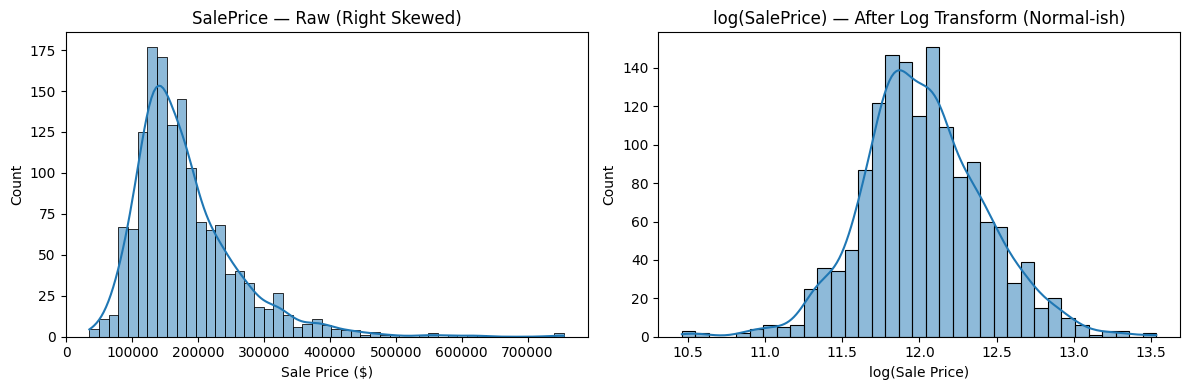

In [ ]:
#Exploring the target variable

# Before touching anything, we need to understand what we're predicting.
# This is one of the most important and most skipped steps by juniors.
#
# Linear regression has an assumption baked in: it works best when
# the target variable is roughly normally distributed (bell-shaped).
# If the target is heavily skewed, the model will struggle because
# it'll spend too much effort trying to predict the extreme values.
#
# Let's look at SalePrice and see if it's skewed.

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True)
# This will show a right-skewed distribution — most houses are in the
# $100k–$300k range, but a few go up to $700k+.
# That long right tail is a problem for linear regression.
plt.title('SalePrice — Raw (Right Skewed)')
plt.xlabel('Sale Price ($)')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['SalePrice']), kde=True)
# log1p(x) means log(1 + x). The +1 is a safety measure in case
# any value is 0 (log(0) is undefined / negative infinity).
# For house prices which are all positive and large, log1p ≈ log.
#
# Notice how this histogram looks much more bell-shaped.
# This is why we log-transform the target — it makes the problem
# easier for a linear model to learn.
plt.title('log(SalePrice) — After Log Transform (Normal-ish)')
plt.xlabel('log(Sale Price)')

plt.tight_layout()
plt.show()

# Now we create a new column with the log-transformed target.
# This is what we'll actually train the model to predict.
# At the very end, we'll reverse this with np.expm1() to get
# dollar predictions back.
df['LogSalePrice'] = np.log1p(df['SalePrice'])


In [ ]:
#handling missing values

# Real-world data is messy. Almost every dataset has missing values (NaN).
# sklearn models cannot handle NaN — they'll throw an error.
# So we need to deal with every single NaN before modeling.
#
# The key insight with Ames Housing:
# Most NaN values here don't mean "data is missing" —
# they mean "this feature doesn't exist for this house."
# For example, PoolQC = NaN doesn't mean we forgot to record pool quality.
# It means THE HOUSE HAS NO POOL.
#
# This distinction matters a lot. If we filled pool quality with the
# average pool quality, we'd be lying — we'd be saying every house
# has a pool of average quality. The right answer is 'None' (no pool).

# First, let's see the scale of the problem
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
# Study this output. It tells you which columns need attention
# and how severe the missingness is.
# If a column is 95% missing, it's probably not worth keeping at all.


# ── Categorical columns where NaN means "doesn't exist" ──────
#
# These are all quality/condition/type columns for features
# that many houses simply don't have (pool, garage, basement, etc.)
# We fill them with the string 'None' which represents "not applicable".

cat_cols_fillnone = [
    'PoolQC',       # Pool quality      — NaN = no pool
    'MiscFeature',  # Misc feature      — NaN = no misc feature
    'Alley',        # Alley access type — NaN = no alley
    'Fence',        # Fence quality     — NaN = no fence
    'FireplaceQu',  # Fireplace quality — NaN = no fireplace
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',  # NaN = no garage
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',  # NaN = no basement
    'MasVnrType'    # Masonry veneer type — NaN = no masonry veneer
]
for col in cat_cols_fillnone:
    if col in df.columns:            # Guard: only try to fill if column actually exists
        df[col] = df[col].fillna('None')


# ── Numeric columns where NaN means 0 ───────────────────────
#
# Same logic but for numeric columns.
# No garage → GarageArea = 0, GarageCars = 0, etc.
# We also use pd.to_numeric() here because fetch_openml sometimes
# gives us numeric values stored as strings, which would cause
# math operations to fail silently or throw errors.

num_cols_fill0 = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',          # Garage measurements
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',            # Basement area measurements
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',      # Basement totals
    'MasVnrArea'                                          # Masonry veneer area
]
for col in num_cols_fill0:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        # errors='coerce': if a value can't be converted to a number,
        # turn it into NaN instead of crashing. Then fillna(0) handles it.


# ── LotFrontage: smarter imputation ─────────────────────────
#
# LotFrontage = linear feet of street connected to the property.
# This one IS genuinely missing data (not "doesn't exist").
# A simple fix would be to fill with the overall median, but we can do better.
#
# Houses in the same neighborhood tend to have similar lot frontages
# (neighborhoods are planned with similar street layouts).
# So we fill each NaN with the MEDIAN of its own neighborhood.
# This is called "group-wise imputation" and it's much more realistic
# than a global median.

df['LotFrontage'] = pd.to_numeric(df['LotFrontage'], errors='coerce')
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
# groupby('Neighborhood') splits the data into neighborhood groups.
# .transform() applies a function to each group but keeps the original index,
# so the result aligns perfectly back with our DataFrame.
# The lambda fills NaNs within each group using that group's own median.


# ── Remaining small categorical NaNs ────────────────────────
#
# A handful of columns have just 1-2 NaNs.
# For these, filling with the most common value (mode) is fine.
# It's a small enough imputation that it won't meaningfully affect results.

for col in ['Electrical', 'MSZoning', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])
        # .mode() returns the most frequent value(s) as a Series.
        # [0] gets the first (most frequent) one.


# ── Drop columns that are mostly missing ─────────────────────
#
# Alley, PoolQC, Fence, MiscFeature are 80-93% missing.
# Even after filling with 'None', they carry very little signal.
# More 'None' than actual data means the model can't learn much from them.
# Dropping them keeps our feature space cleaner.

cols_to_drop = [c for c in ['Alley', 'PoolQC', 'Fence', 'MiscFeature'] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)


# ── Force remaining numeric columns to correct dtype ────────
#
# fetch_openml is notorious for loading numeric columns as 'object' dtype.
# If we don't fix this, pandas will treat numbers like strings and
# arithmetic operations will either fail or give nonsense results.

numeric_cols = [
    'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
    'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
    'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
    'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
    'PoolArea', 'MiscVal', 'MoSold', 'YrSold'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageCond        81
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrType         8
MasVnrArea         8
Electrical         1
dtype: int64


In [ ]:
#ensuring numeric columns are the right datatype

# fetch_openml sometimes loads numeric columns as 'object' (string) dtype
# We force-convert all columns that should be numeric

numeric_cols = ['LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
                'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
                'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
                'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
                'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
                'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
                'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

In [ ]:
#feature engineering

df# Feature engineering is where domain knowledge meets math.
# The raw dataset gives us individual measurements, but sometimes
# COMBINATIONS of features are more predictive than any single one.
#
# Think about it from a buyer's perspective:
# "How big is this house TOTAL?" is more useful than asking
# "How big is the basement?" and "How big is the first floor?"
# separately. We create features that capture these intuitions.
#
# Good feature engineering can matter more than which model you pick.

df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
# Total square footage of the entire house.
# In practice, this is usually the single most predictive feature.
# Buyers pay for space — this captures total space in one number.

df['TotalBathrooms'] = (df['FullBath']
                        + 0.5 * df['HalfBath']
                        + df['BsmtFullBath']
                        + 0.5 * df['BsmtHalfBath'])
# Combining all bathroom counts into one number.
# Half bathrooms (no shower/tub) count as 0.5 — a reasonable approximation
# of their relative value compared to full bathrooms.

df['HouseAge'] = df['YrSold'] - df['YearBuilt']
# Age of the house at the time of sale.
# A 5-year-old house and a 50-year-old house are very different products.
# Raw YearBuilt is less intuitive than age because it depends on YrSold.

df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
# How long ago was the house renovated?
# A 50-year-old house renovated 2 years ago is worth more than one
# renovated 30 years ago. This captures that recency effect.

df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
# Binary flags: does this house HAVE this feature at all?
# (df['GarageArea'] > 0) returns True/False.
# .astype(int) converts True → 1, False → 0.
# These simple yes/no features often add signal on top of the continuous ones.


df['Qual_TotalSF'] = df['OverallQual'] * df['TotalSF']
# Interaction feature: quality score multiplied by size.
# The intuition: 3,000 sq ft of high-quality construction is worth
# much more than 3,000 sq ft of low-quality construction.
# Linear regression can't capture this on its own because it treats
# each feature independently. Multiplying them creates that interaction.


In [ ]:
#Encoding categorical variables

#Linear regression is pure math — it multiplies features by coefficients
# and adds them up. It can only do this with NUMBERS.
# Strings like 'Gd' (Good) or 'CollgCr' (neighborhood name) mean nothing
# to the math. We need to convert them to numbers.
#
# There are two fundamentally different ways to do this,
# and choosing the wrong one can hurt your model:
#
# 1. ORDINAL ENCODING — for categories that have a natural order
#    (Poor < Fair < Average < Good < Excellent)
#    We map them to integers that preserve this ordering.
#
# 2. ONE-HOT ENCODING — for categories with NO natural order
#    (Neighborhood names, house styles, sale conditions)
#    There's no math sense in saying CollgCr > Sawyer.
#    Instead we create a separate binary column for each category.


# ── Ordinal encoding for quality/condition columns ───────────

quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
# None = Not Applicable (no feature)
# Po = Poor, Fa = Fair, TA = Typical/Average, Gd = Good, Ex = Excellent
# The integers preserve the ordering: Ex (5) > Gd (4) > TA (3), etc.
# This is correct because quality IS ordered — Excellent really is better than Good.

ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond']
for col in ordinal_cols:
    if col in df.columns:
        df[col] = df[col].map(quality_map)
        # .map() replaces each value using the dictionary.
        # Any value not in the dict becomes NaN, so we fill those with 0.
        df[col] = df[col].fillna(0)

# ── One-hot encoding for all remaining categorical columns ───

df = pd.get_dummies(df, drop_first=True)
# pd.get_dummies() finds every column with string (object) dtype
# and converts it to multiple binary (0/1) columns.
#
# Example: 'Neighborhood' has 25 unique values.
# After get_dummies, you get 24 new columns like:
#   Neighborhood_BrkSide, Neighborhood_CollgCr, etc.
# Each is 1 if the house is in that neighborhood, 0 otherwise.
#
# drop_first=True drops ONE column per feature.
# Why? If you have 25 neighborhoods and 24 are 0,
# you already know it's the 25th. The 25th column is redundant.
# Keeping it causes "perfect multicollinearity" which breaks OLS math.
# (XᵀX becomes singular and can't be inverted.)




In [ ]:
#preparing features and targer - train/test split

# We need to split our data into two completely separate sets:
#
# TRAINING SET (~80%): The model sees this data and learns from it.
# TEST SET (~20%): The model NEVER sees this during training.
#                 We use it at the very end to simulate real-world
#                 performance on houses it's never encountered.
#
# Why do we need this split?
# A model can always get 100% accuracy on data it trained on —
# it just memorizes it. That tells us nothing about how it performs
# on NEW houses. The test set is our reality check.
#
# Think of it like studying for an exam:
# Training set = the practice problems you study with.
# Test set = the actual exam with questions you've never seen.

target = 'LogSalePrice'
drop_cols = [c for c in ['SalePrice', 'LogSalePrice', 'Id'] if c in df.columns]
# We drop:
# - 'SalePrice': the raw price — can't use the answer as a feature
# - 'LogSalePrice': our target — goes in y, not X
# - 'Id': just a row number, carries zero predictive information

X = df.drop(columns=drop_cols)     # Features — everything the model can use
y = df[target]                     # Target — what we're trying to predict

print(f"Features: {X.shape[1]} columns, {X.shape[0]} rows")
print(f"Target: {y.shape[0]} rows")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% of rows go to test set, 80% to training
    random_state=42     # Fixing the random seed means every time you run this,
                        # you get the exact same split. Reproducibility matters —
                        # you want to know if a model change improved things,
                        # not just if you got a luckier split.
)

print(f"Training set: {X_train.shape[0]} houses")
print(f"Test set:     {X_test.shape[0]} houses")



Features: 227 columns, 1460 rows
Target: 1460 rows
Training set: 1168 houses
Test set:     292 houses


In [ ]:
#Feature Scaling

# Here's the problem we're solving:
#
# 'LotArea' ranges from ~1,300 to ~215,000 (square feet)
# 'OverallQual' ranges from 1 to 10
# 'HalfBath' ranges from 0 to 2
#
# When gradient descent computes gradients, the gradient for LotArea
# will be HUGE compared to HalfBath — not because LotArea matters more,
# just because its numbers are bigger. The optimizer will zigzag
# toward the LotArea direction and ignore smaller-scale features.
#
# Standardization fixes this: for every feature, subtract its mean
# and divide by its standard deviation. Result: every feature has
# mean = 0 and std = 1. Now they're all on equal footing.
#
# CRITICAL RULE: Fit the scaler ONLY on training data.
# If you fit on all data (including test), information from the test
# set leaks into your preprocessing. The model indirectly "sees"
# the test data before evaluation. This is called DATA LEAKAGE
# and it makes your reported performance overly optimistic.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
# fit_transform does two things in one step:
# 1. fit: compute mean and std of EACH column FROM TRAINING DATA
# 2. transform: apply (x - mean) / std to every value

X_test_scaled = scaler.transform(X_test)
# transform ONLY — we use the means and stds we learned from training.
# We do NOT refit. This ensures test data is scaled the same way
# training data was, using only information available at training time.



In [ ]:
#training and evaluating models

# We'll train four models and compare them.
# Each one minimizes MSE, but with different constraints:
#
# LinearRegression: pure OLS, no constraints, finds the globally
#                   optimal β for training data. Can overfit badly
#                   with many features.
#
# Ridge (L2):       adds λ·Σβ² to the loss. Shrinks all coefficients
#                   toward zero. Never sets any exactly to zero.
#                   Better when many features are useful.
#
# Lasso (L1):       adds λ·Σ|β| to the loss. Actually drives some
#                   coefficients to exactly zero — automatic feature
#                   selection. Better when few features matter.
#
# ElasticNet:       combines L1 + L2. Gets Lasso's sparsity with
#                   Ridge's stability. Best of both worlds when
#                   features are correlated

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """
    Train a model and print its RMSE and R² on the test set.

    RMSE (Root Mean Squared Error):
        Average prediction error in log(price) units.
        RMSE of 0.15 ≈ predictions off by ~15% in actual dollars.
        Lower is better.

    R² (R-squared / Coefficient of Determination):
        What fraction of price variation does our model explain?
        R² = 1.0 → perfect predictions
        R² = 0.0 → no better than always predicting the mean
        R² < 0.0 → worse than predicting the mean (model is broken)
        Higher is better.
    """

    model.fit(X_tr, y_tr)                                  # Train: learn β from training data
    preds = model.predict(X_te)                            # Predict: apply β to test features
    rmse = np.sqrt(mean_squared_error(y_te, preds))        # Compute RMSE
    r2 = r2_score(y_te, preds)                             # Compute R²
    print(f"{name:<35} RMSE: {rmse:.4f}   R²: {r2:.4f}")
    return model, preds


print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)


lr_model,    preds_lr    = evaluate("Linear Regression",
                                     LinearRegression(),
                                     X_train_scaled, y_train,
                                     X_test_scaled, y_test)

ridge_model, preds_ridge = evaluate("Ridge Regression (α=10)",
                                     Ridge(alpha=10.0),
                                     X_train_scaled, y_train,
                                     X_test_scaled, y_test)

lasso_model, preds_lasso = evaluate("Lasso Regression (α=0.001)",
                                     Lasso(alpha=0.001, max_iter=10000),
                                     X_train_scaled, y_train,
                                     X_test_scaled, y_test)
# max_iter=10000: Lasso uses an iterative solver (coordinate descent).
# The default 1000 iterations sometimes isn't enough to converge.
# We give it more iterations to ensure it actually finds the minimum.


enet_model,  preds_enet  = evaluate("ElasticNet (α=0.001, ratio=0.5)",
                                     ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
                                     X_train_scaled, y_train,
                                     X_test_scaled, y_test)
# l1_ratio=0.5 means 50% L1 penalty, 50% L2 penalty.
# You can tune this too — closer to 1 = more Lasso-like,
# closer to 0 = more Ridge-like.

# How many features did Lasso eliminate entirely?
n_zero = np.sum(lasso_model.coef_ == 0)
n_total = len(lasso_model.coef_)
print(f"\nLasso zeroed out {n_zero} of {n_total} features")
print(f"It's using only {n_total - n_zero} features to make predictions")
# This is Lasso's feature selection in action.
# It decided those zeroed features contributed nothing useful.

MODEL COMPARISON
Linear Regression                   RMSE: 0.1907   R²: 0.8051
Ridge Regression (α=10)             RMSE: 0.1545   R²: 0.8720
Lasso Regression (α=0.001)          RMSE: 0.1687   R²: 0.8474
ElasticNet (α=0.001, ratio=0.5)     RMSE: 0.1761   R²: 0.8338

Lasso zeroed out 67 of 227 features
It's using only 160 features to make predictions


In [ ]:
# finetuning strength with cross validation

# We picked α=10 for Ridge somewhat arbitrarily. Let's find the
# best value properly using cross-validation.
#
# What is cross-validation?
# Instead of one 80/20 split, we do FIVE different splits.
# Split 1: train on parts 2,3,4,5 — test on part 1
# Split 2: train on parts 1,3,4,5 — test on part 2
# ... and so on.
# We average the 5 test scores to get a stable performance estimate.
#
# Why is this better than one split?
# One split can be lucky or unlucky depending on which houses ended up
# in the test set. 5-fold CV averages out that randomness.
# The ± standard deviation tells you how stable the performance is.
#
# IMPORTANT: We only do this on training data.
# The test set stays completely locked until the very end.


alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
cv_rmses = []

print("\nCross-validation results for Ridge:")
print("-" * 40)

for alpha in alphas:
    scores = cross_val_score(
        Ridge(alpha=alpha),
        X_train_scaled,
        y_train,
        cv=5,                                       # 5-fold CV
        scoring='neg_root_mean_squared_error'       # sklearn always maximizes scores,
                                                    # so it uses negative RMSE.
                                                    # We flip the sign back below.
    )

    mean_rmse = -scores.mean()      # Flip sign: neg RMSE → positive RMSE
    std_rmse = scores.std()         # Standard deviation across the 5 folds
    cv_rmses.append(mean_rmse)
    print(f"  α={alpha:<8} → CV RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")

    best_alpha = alphas[np.argmin(cv_rmses)]
    # np.argmin returns the INDEX of the smallest value in cv_rmses.
    # alphas[that_index] gives us the corresponding alpha value.
    print(f"\nBest alpha: {best_alpha}")


# ── Retrain with best alpha on full training set ─────────────
#
# Once we've identified the best alpha via CV, we retrain on ALL
# training data (not just 4/5 of it). More data = better model.
# Then we evaluate ONCE on the test set.

best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X_train_scaled, y_train)
best_preds = best_ridge.predict(X_test_scaled)

final_rmse = np.sqrt(mean_squared_error(y_test, best_preds))
final_r2 = r2_score(y_test, best_preds)
print(f"\nFinal Model (Ridge α={best_alpha})")
print(f"Test RMSE: {final_rmse:.4f}")
print(f"Test R²:   {final_r2:.4f}")



Cross-validation results for Ridge:
----------------------------------------
  α=0.01     → CV RMSE: 0.1892 ± 0.0391

Best alpha: 0.01
  α=0.1      → CV RMSE: 0.1876 ± 0.0380

Best alpha: 0.1
  α=1.0      → CV RMSE: 0.1797 ± 0.0335

Best alpha: 1.0
  α=10.0     → CV RMSE: 0.1615 ± 0.0288

Best alpha: 10.0
  α=100.0    → CV RMSE: 0.1519 ± 0.0311

Best alpha: 100.0
  α=1000.0   → CV RMSE: 0.1489 ± 0.0291

Best alpha: 1000.0

Final Model (Ridge α=1000.0)
Test RMSE: 0.1489
Test R²:   0.8812


In [ ]:
#interpreting the coefficients

# One of the biggest advantages of linear regression over complex
# models like neural networks: it's interpretable.
# Each coefficient β tells you the effect of that feature on price.
#
# Because we standardized features, coefficients are directly comparable.
# A feature with β=0.3 has 3x more influence than one with β=0.1.
# This is NOT true if you don't standardize — then coefficients depend
# on the scale of the feature, not just its importance.
#
# Positive β → higher value of this feature → higher predicted price
# Negative β → higher value of this feature → lower predicted price

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_ridge.coef_
})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()   # Importance = absolute value of coefficient
coef_df = coef_df.sort_values('AbsCoef', ascending=False).reset_index(drop=True)

print("\nTop 20 Most Influential Features:")
print("-" * 50)
print(coef_df.head(20).to_string(index=False))
# You should see TotalSF, OverallQual, Qual_TotalSF near the top.
# These make intuitive sense — size and quality drive price most.
# Negative coefficients might include HouseAge (older = cheaper).


Top 20 Most Influential Features:
--------------------------------------------------
             Feature  Coefficient  AbsCoef
         OverallQual     0.030358 0.030358
           GrLivArea     0.022341 0.022341
             TotalSF     0.019168 0.019168
          GarageCars     0.018796 0.018796
        Qual_TotalSF     0.018790 0.018790
        TotRmsAbvGrd     0.017658 0.017658
         OverallCond     0.017183 0.017183
      TotalBathrooms     0.016808 0.016808
            1stFlrSF     0.016543 0.016543
         FireplaceQu     0.016182 0.016182
         KitchenQual     0.016178 0.016178
          GarageArea     0.015708 0.015708
          Fireplaces     0.014544 0.014544
            BsmtQual     0.014537 0.014537
Neighborhood_NridgHt     0.014114 0.014114
Neighborhood_Crawfor     0.012905 0.012905
        CentralAir_Y     0.012758 0.012758
           ExterQual     0.012695 0.012695
            FullBath     0.012498 0.012498
Neighborhood_StoneBr     0.012071 0.012071


In [ ]:
#converting predictions back to dollars

# Remember, we trained on log(SalePrice), not SalePrice.
# Our predictions are in log space. We need to reverse the
# transformation to get actual dollar values.
#
# We used: LogSalePrice = log1p(SalePrice)
# So inverse is: SalePrice = expm1(LogSalePrice)
# expm1(x) = e^x - 1  (the mathematically exact inverse of log1p)

y_pred_dollars = np.expm1(best_preds)
y_true_dollars = np.expm1(y_test)

rmse_dollars = np.sqrt(mean_squared_error(y_true_dollars, y_pred_dollars))
mae_dollars = np.mean(np.abs(y_true_dollars - y_pred_dollars))
# MAE = Mean Absolute Error = average absolute gap between prediction and truth.
# More interpretable than RMSE because it's in plain dollars with no squaring.

print(f"\nFinal Performance in Actual Dollars:")
print(f"  RMSE: ${rmse_dollars:>10,.0f}   (penalizes large errors more)")
print(f"  MAE:  ${mae_dollars:>10,.0f}   (average absolute error)")
# e.g., MAE of $18,000 means on average our predictions are $18k off.
# For a $180,000 house that's 10% — pretty good for a linear model!



Final Performance in Actual Dollars:
  RMSE: $    28,399   (penalizes large errors more)
  MAE:  $    17,022   (average absolute error)


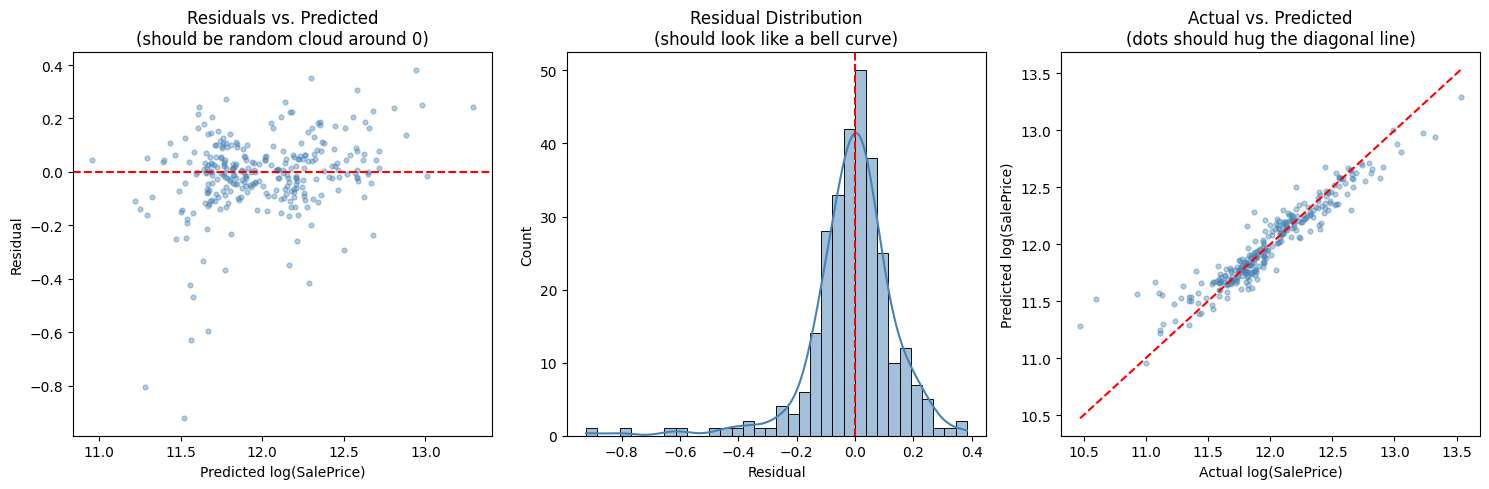

In [ ]:
#residual analysis

# A residual = actual value − predicted value.
# Residual analysis is how we verify that linear regression's
# assumptions actually hold for our data.
#
# The key assumption: residuals should be RANDOM NOISE.
# Specifically:
#   1. Centered at zero (no systematic over/under-prediction)
#   2. Constant spread (no funnel shape — called homoscedasticity)
#   3. Normally distributed
#   4. No pattern with respect to predictions
#
# If these are violated, it means:
#   - Funnel shape → your model uncertainty grows for expensive houses
#   - Curve/pattern → the relationship is non-linear; linear model is wrong
#   - Non-normal → standard errors and confidence intervals are unreliable


residuals = y_test.values - best_preds     # Compute residuals in log scale

plt.figure(figsize=(15, 5))

# ── Plot 1: Residuals vs. Predicted ──────────────────────────
plt.subplot(1, 3, 1)
plt.scatter(best_preds, residuals, alpha=0.4, s=12, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted log(SalePrice)')
plt.ylabel('Residual')
plt.title('Residuals vs. Predicted\n(should be random cloud around 0)')


# What to look for:
# ✓ GOOD: Symmetric cloud of dots around the red line, uniform thickness
# ✗ BAD: Funnel shape (getting wider) = heteroscedasticity
# ✗ BAD: Curved pattern = non-linear relationship we're not capturing

# ── Plot 2: Distribution of Residuals ────────────────────────
plt.subplot(1, 3, 2)
sns.histplot(residuals, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.title('Residual Distribution\n(should look like a bell curve)')
# ✓ GOOD: Roughly bell-shaped, centered near 0
# ✗ BAD: Skewed or heavy-tailed = OLS assumptions violated

# ── Plot 3: Actual vs. Predicted ─────────────────────────────
plt.subplot(1, 3, 3)
plt.scatter(y_test, best_preds, alpha=0.4, s=12, color='steelblue')
# Draw a perfect prediction line (actual = predicted)
min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
plt.xlabel('Actual log(SalePrice)')
plt.ylabel('Predicted log(SalePrice)')
plt.title('Actual vs. Predicted\n(dots should hug the diagonal line)')
# ✓ GOOD: Dots tightly clustered along the diagonal red line
# ✗ BAD: Dots far from diagonal, or systematic curve above/below it

plt.tight_layout()
plt.show()


In [ ]:
#final summary

print("\n" + "=" * 60)
print("WHAT WE BUILT AND WHY EACH STEP MATTERED")
print("=" * 60)
print("""
1. Log-transformed target   → Fixed right skew, made MSE more meaningful
2. Smart missing value fill → Preserved meaning (NaN ≠ unknown, NaN = absent)
3. Group-wise imputation    → More realistic than global median
4. Feature engineering      → Gave the model domain knowledge it couldn't learn alone
5. Ordinal encoding         → Preserved quality ordering (Ex > Gd > TA)
6. One-hot encoding         → Converted nominal categories without false ordering
7. Train/test split         → Honest evaluation on unseen data
8. Feature scaling          → Equal footing for gradient descent + interpretable coefficients
9. Regularization           → Prevented overfitting with 200+ features and 1,460 rows
10. Cross-validation        → Reliable alpha selection without touching the test set
11. Residual analysis       → Verified model assumptions actually hold
""")


WHAT WE BUILT AND WHY EACH STEP MATTERED

1. Log-transformed target   → Fixed right skew, made MSE more meaningful
2. Smart missing value fill → Preserved meaning (NaN ≠ unknown, NaN = absent)
3. Group-wise imputation    → More realistic than global median
4. Feature engineering      → Gave the model domain knowledge it couldn't learn alone
5. Ordinal encoding         → Preserved quality ordering (Ex > Gd > TA)
6. One-hot encoding         → Converted nominal categories without false ordering
7. Train/test split         → Honest evaluation on unseen data
8. Feature scaling          → Equal footing for gradient descent + interpretable coefficients
9. Regularization           → Prevented overfitting with 200+ features and 1,460 rows
10. Cross-validation        → Reliable alpha selection without touching the test set
11. Residual analysis       → Verified model assumptions actually hold

